### Trader performance and market sentiments

Analyze whether Bitcoin market sentiment (Fear/Greed) affects trader behavior and profitability using:

- Bitcoin Sentiment Dataset
- Hyperliquid Historical Trader Data


In [1]:
import pandas as pd
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

### Data Preprocessing

In [2]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
trades['Clean_Date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce').dt.date
sentiment['Clean_Date'] = pd.to_datetime(sentiment['date']).dt.date

In [12]:
merged_df = pd.merge(trades, sentiment[['Clean_Date', 'value', 'classification']], on='Clean_Date', how='inner')

In [13]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Clean_Date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80,Extreme Greed


### EDA

In [15]:
merged_df['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [17]:
merged_df.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


Let's see if traders lose more money when ("Greed") vs. buying panic ("Fear").

In [19]:
# Aggregate PnL and Win Rate by Market Sentiment
pnl_summary = merged_df.groupby('classification').agg(
    Total_Trades=('Closed PnL', 'count'),
    Total_PnL=('Closed PnL', 'sum'),
    Avg_PnL=('Closed PnL', 'mean'),
    Win_Rate=('Closed PnL', lambda x: (x > 0).sum() / len(x) * 100)
).reset_index()

print("--- Trader Performance vs Market Sentiment ---")
print(pnl_summary)

--- Trader Performance vs Market Sentiment ---
  classification  Total_Trades     Total_PnL    Avg_PnL   Win_Rate
0   Extreme Fear         21400  7.391102e+05  34.537862  37.060748
1  Extreme Greed         39992  2.715171e+06  67.892861  46.494299
2           Fear         61837  3.357155e+06  54.290400  42.076750
3          Greed         50303  2.150129e+06  42.743559  38.482794
4        Neutral         37686  1.292921e+06  34.307718  39.699093


- Fear has the highest total profit.
Most people assume "Greed markets are most profitable" But data suggests "Traders collectively earned most during normal fear".
- Extreme Greed Has the Highest Average Profit
- Extreme Greed Also Has the Highest Win Rate
- Greed Performs Worse Than Fear in AVG_pnl and win rate, possible reasons: Overconfident, crowded trades, poor risk managements.

In [33]:
merged_df.groupby('classification')['Closed PnL'].agg([
    'mean',
    'median',
    'std',
    'min',
    'max'
])

,mean,median,std,min,max
classification,,,,,
Extreme Fear,34.537862,0.0,1136.056091,-31036.69194,115287.00000
Extreme Greed,67.892861,0.0,766.828294,-10259.46800,44223.45187
Fear,54.290400,0.0,935.355438,-35681.74723,135329.09010
Greed,42.743559,0.0,1116.028390,-117990.10410,74530.52371
Neutral,34.307718,0.0,517.122220,-24500.00000,48504.09555


In [23]:
merged_df['Direction'].unique()

array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)

In [20]:
merged_df.groupby(['classification', 'Direction'])['Closed PnL'].mean()

classification  Direction                
Extreme Fear    Buy                              0.000000
                Close Long                      81.197371
                Close Short                    123.400238
                Long > Short                     1.331956
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                          -135.021730
                Short > Long                 -1932.516940
                Spot Dust Conversion             0.000000
Extreme Greed   Buy                              0.000000
                Close Long                      61.830783
                Close Short                     28.970490
                Long > Short                   120.600968
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                           290.572354
                Short > Long                    11.771238
                Spot Dust Conversion             0.000000
Fear            Buy                              0.000000
                Close Long                      83.000111
                Close Short                    207.676658
                Long > Short                     4.795642
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                            -3.141217
                Short > Long                  1115.943156
                Spot Dust Conversion             0.000000
Greed           Auto-Deleveraging             7184.807003
                Buy                              0.000000
                Close Long                      88.958554
                Close Short                     55.195496
                Liquidated Isolated Short   -12752.913040
                Long > Short                    22.711911
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                           128.022106
                Settlement                     -29.215368
                Short > Long                   100.665716
                Spot Dust Conversion             0.000000
Neutral         Buy                              0.000000
                Close Long                      52.815787
                Close Short                     94.796313
                Long > Short                    47.332193
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                            89.517239
                Short > Long                   -11.945100
                Spot Dust Conversion             0.000000
Name: Closed PnL, dtype: float64

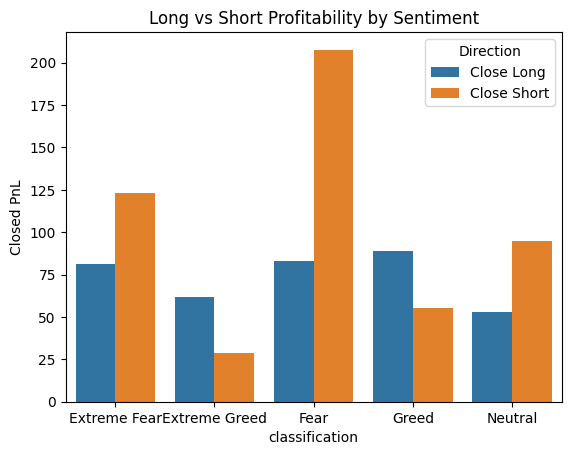

In [47]:
filtered = direction_perf[
    direction_perf['Direction'].isin(
        ['Close Long', 'Close Short']
    )
]

sns.barplot(
    data=filtered,
    x='classification',
    y='Closed PnL',
    hue='Direction'
)

plt.title("Long vs Short Profitability by Sentiment")
plt.show()

#### Which trading direction works in which sentiment, liquidation behavior

In [35]:
direction_perf = merged_df.groupby(
    ['classification', 'Direction']
)['Closed PnL'].mean().reset_index()

print(direction_perf)

   classification                  Direction    Closed PnL
0    Extreme Fear                        Buy      0.000000
1    Extreme Fear                 Close Long     81.197371
2    Extreme Fear                Close Short    123.400238
3    Extreme Fear               Long > Short      1.331956
4    Extreme Fear                  Open Long      0.000000
5    Extreme Fear                 Open Short      0.000000
6    Extreme Fear                       Sell   -135.021730
7    Extreme Fear               Short > Long  -1932.516940
8    Extreme Fear       Spot Dust Conversion      0.000000
9   Extreme Greed                        Buy      0.000000
10  Extreme Greed                 Close Long     61.830783
11  Extreme Greed                Close Short     28.970490
12  Extreme Greed               Long > Short    120.600968
13  Extreme Greed                  Open Long      0.000000
14  Extreme Greed                 Open Short      0.000000
15  Extreme Greed                       Sell    290.5723

- Close Short Performs Extremely Well During Fear:

- short sellers made huge profits during fear markets

- Extreme Fear Sell Trades Are Deeply Negative

- Liquidated Isolated Short in Greed = HUGE NEGATIVE, Short traders got liquidated during Greed.


#### Let's figure out if the top-tier, consistently profitable accounts trade differently from the herd when sentiment hits extremes.

In [29]:
# 1. Find total PnL per unique account
account_performance = merged_df.groupby('Account')['Closed PnL'].sum().reset_index()

# 2. Identify the top 10% most profitable accounts
threshold = account_performance['Closed PnL'].quantile(0.90)
top_accounts = account_performance[account_performance['Closed PnL'] >= threshold]['Account']

# 3. Filter the main dataset for these pro traders
pro_traders_df = merged_df[merged_df['Account'].isin(top_accounts)]

# 4. See what these pro traders do during "Extreme Fear" vs the rest of the market
pro_behavior = pro_traders_df.groupby('classification').agg(
    Pro_Avg_PnL=('Closed PnL', 'mean'),
    Pro_Win_Rate=('Closed PnL', lambda x: (x > 0).sum() / len(x) * 100)
).reset_index()

print("\n--- Pro Trader Behavior Across Sentiment Cycles ---")
print(pro_behavior)


--- Pro Trader Behavior Across Sentiment Cycles ---
  classification  Pro_Avg_PnL  Pro_Win_Rate
0   Extreme Fear    57.389282     36.575463
1  Extreme Greed   378.876743     32.052650
2           Fear    94.589772     44.532563
3          Greed   101.051141     30.040469
4        Neutral    90.544663     46.488514


Conclusions:
- Pro Traders Earn MASSIVE Profits During Extreme Greed
#### BUT Their Win Rate Is Surprisingly LOW
This reveals: They do not win often, but when they win, they win big!

- During calmer conditions:

pro traders become more accurate
trades become more controlled
fewer emotional distortions exist

- Greed Win rate is LOW,means:
normal greed markets may be noisy, overconfidence increases false signals

In [37]:
merged_df['trader_type'] = pd.qcut(
    merged_df['Size USD'],
    q=3,
    labels=['Small', 'Medium', 'Whale']
)

In [39]:
merged_df.groupby(
    ['classification', 'trader_type']
)['Closed PnL'].mean()

/tmp/ipykernel_1258/253518637.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby(


classification  trader_type
Extreme Fear    Small           -0.294766
                Medium           5.780856
                Whale           86.054507
Extreme Greed   Small            6.694096
                Medium          28.301795
                Whale          192.633660
Fear            Small            1.968209
                Medium          10.389969
                Whale          139.068344
Greed           Small            2.623917
                Medium          12.808271
                Whale          114.312906
Neutral         Small            1.048531
                Medium           7.159185
                Whale          101.578799
Name: Closed PnL, dtype: float64

Whale traders remain profitable even during Fear periods, while smaller traders experience larger relative losses.

Traders become significantly more active during Greed periods.

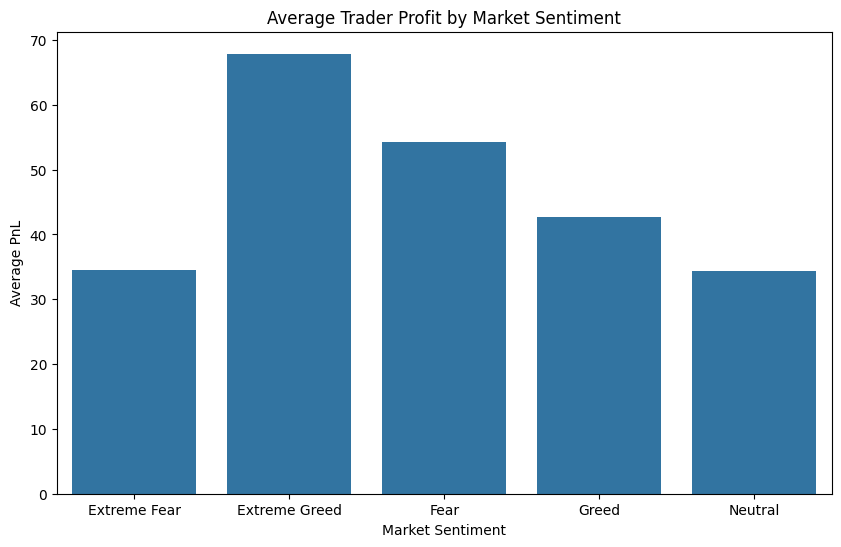

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=pnl_summary,
    x='classification',
    y='Avg_PnL'
)

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

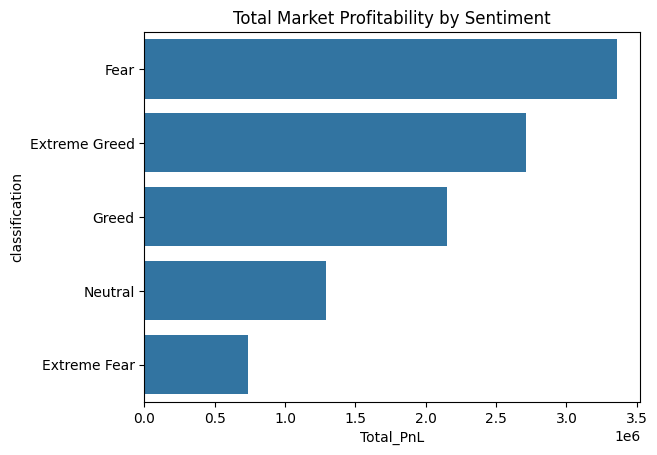

In [45]:
sns.barplot(
    data=pnl_summary.sort_values(
        by='Total_PnL',
        ascending=False
    ),
    y='classification',
    x='Total_PnL'
)

plt.title("Total Market Profitability by Sentiment")
plt.show()